# Judge Comparison Heatmap

Three figures:
1. **4-panel judge comparison** — one panel per judge (DeepSeek-R1, Gemini-2.5-Flash-Lite, GPT-4.1-Mini, Claude-Sonnet-4.6), each showing per-generator-model scores across 3 dimensions + Overall side panel.
2. **Strategy comparison** — all 12 LLMs × 3 analogy strategies (Baseline | Embedding | Rerank) + Retrieval-Based reference row, averaged across all 4 judges.
3. **Inter-judge agreement** — pairwise Spearman correlation heatmaps (per dimension) + dendrogram showing which judges are closest to each other.

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR   = Path('../results')
JUDGE_DIR  = BASE_DIR / 'upgraded_llm'
OUTPUT_DIR = BASE_DIR / 'judge_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Global font style (sans-serif throughout) ──────────────────────────────
plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  ['Arial', 'DejaVu Sans', 'Helvetica', 'Liberation Sans'],
    'font.size':         9,
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
})

# ── Judge config ───────────────────────────────────────────────────────────
JUDGES = [
    {'key': 'deepseek-r1',           'display': 'DeepSeek-R1',           'color': '#d7191c'},
    {'key': 'gemini-2.5-flash-lite', 'display': 'Gemini-2.5-Flash-Lite', 'color': '#f4a23a'},
    {'key': 'gpt-4.1-mini',          'display': 'GPT-4.1-Mini',          'color': '#2166ac'},
    {'key': 'claude-sonnet-4.6',     'display': 'Claude Sonnet 4.6',     'color': '#7b3294'},
]

# ── Generator model display names ──────────────────────────────────────────
MODEL_DISPLAY = {
    'deepseek-r1':                'DeepSeek-R1',
    'gemini-2.5-flash-lite':      'Gemini-2.5-Flash',
    'gpt-4.1-mini':               'GPT-4.1-Mini',
    'gpt-4.1-nano':               'GPT-4.1-Nano',
    'gpt-oss-120b':               'GPT-OSS-120B',
    'gpt-oss-20b':                'GPT-OSS-20B',
    'grok-4-fast':                'Grok-4',
    'llama-3.1-405b-instruct':    'Llama-3.1-405B',
    'meta-llama-3-1-70b-instruct':'Llama-3.1-70B',
    'meta-llama-3-1-8b-instruct': 'Llama-3.1-8B',
    'qwen3-14b':                  'Qwen3-14B',
    'qwen3-32b':                  'Qwen3-32B',
    'retrieval-based':            'Retrieval-Based',
}

# ── Score columns ──────────────────────────────────────────────────────────
DIM_COLS   = ['analogy_coherence', 'mapping_soundness', 'explanatory_power']
DIM_LABELS = ['Coherence', 'Mapping', 'Explanatory']
AVG_COL    = 'average_score'

# ── Custom colormap: #e16f4f → white → #527dc9, centred at 2.0 ────────────
THESIS_CMAP = LinearSegmentedColormap.from_list(
    'thesis',
    ['#e16f4f', '#ffffff', '#527dc9'],
    N=512,
)
VMIN    = 1.3
VCENTER = 2.0
VMAX    = 2.7
NORM    = mcolors.TwoSlopeNorm(vmin=VMIN, vcenter=VCENTER, vmax=VMAX)
CBAR_TICKS = [1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6]

print('Setup complete.')

Setup complete.


In [90]:
# ── Load & filter one judge file ───────────────────────────────────────────
def load_judge(judge_key: str) -> pd.DataFrame:
    """
    Load one fewshot judge CSV and return per-model mean scores.

    Filtering logic (matches judge_agreement_analysis.ipynb):
      - status == 'success'
      - Stage-2 LLMs : source_dataset starts with 'stage2'  AND  analogy_type == 'rerank'
      - Stage-1 baseline: source_dataset starts with 'stage1' AND  analogy_type == 'pipeline_results'

    Returns DataFrame indexed by raw model name.
    """
    fpath = JUDGE_DIR / f'upgraded_judge_3scale_fewshot_{judge_key}.csv'
    df = pd.read_csv(fpath)
    df = df[df['status'] == 'success'].copy()

    stage2 = df[
        df['source_dataset'].str.startswith('stage2') &
        (df['analogy_type'] == 'rerank')
    ]
    stage1 = df[
        df['source_dataset'].str.startswith('stage1') &
        (df['analogy_type'] == 'pipeline_results')
    ]
    combined = pd.concat([stage2, stage1], ignore_index=True)

    means = combined.groupby('model')[DIM_COLS + [AVG_COL]].mean()
    print(f'  {judge_key:30s}: {len(combined):6d} records, {len(means):2d} models')
    return means


print('Loading judge data...')
judge_means = {j['key']: load_judge(j['key']) for j in JUDGES}
print('Done.')

Loading judge data...
  deepseek-r1                   :   7985 records, 13 models
  gemini-2.5-flash-lite         :   7985 records, 13 models
  gpt-4.1-mini                  :   7985 records, 13 models
  claude-sonnet-4.6             :   7984 records, 13 models
Done.


In [91]:
# ── Shared model ordering (best → worst by cross-judge average) ────────────
all_avg = pd.DataFrame({
    j['key']: judge_means[j['key']][AVG_COL]
    for j in JUDGES
})
all_avg['cross_mean'] = all_avg.mean(axis=1)
all_avg = all_avg.sort_values('cross_mean', ascending=False)

shared_raw_order  = all_avg.index.tolist()          # raw model names
shared_disp_order = [MODEL_DISPLAY.get(m, m) for m in shared_raw_order]

print('Shared model order (best → worst):')
for i, (raw, row) in enumerate(all_avg.iterrows(), 1):
    print(f'  {i:2d}. {MODEL_DISPLAY.get(raw, raw):22s}  cross-mean={row["cross_mean"]:.3f}')

Shared model order (best → worst):
   1. Llama-3.1-405B          cross-mean=2.388
   2. DeepSeek-R1             cross-mean=2.353
   3. Grok-4                  cross-mean=2.352
   4. GPT-OSS-120B            cross-mean=2.350
   5. Gemini-2.5-Flash        cross-mean=2.349
   6. Qwen3-14B               cross-mean=2.347
   7. Llama-3.1-70B           cross-mean=2.346
   8. GPT-4.1-Mini            cross-mean=2.329
   9. Qwen3-32B               cross-mean=2.321
  10. GPT-OSS-20B             cross-mean=2.303
  11. Llama-3.1-8B            cross-mean=2.257
  12. GPT-4.1-Nano            cross-mean=2.252
  13. Retrieval-Based         cross-mean=1.773


In [92]:
# ── Helper: draw one panel (heatmap + side bar) ────────────────────────────
def draw_panel(fig, outer_cell, means_df, judge_info):
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        1, 2,
        subplot_spec=outer_cell,
        width_ratios=[3, 0.65],
        wspace=0.03,
    )
    ax_heat = fig.add_subplot(inner_gs[0, 0])
    ax_side = fig.add_subplot(inner_gs[0, 1])

    reindexed = means_df.reindex(shared_raw_order)
    hm = reindexed[DIM_COLS].values   # (n, 3)
    ov = reindexed[AVG_COL].values    # (n,)
    n  = len(shared_raw_order)

    # Per-column index of the highest score (for bold border highlight)
    col_max_row = [
        int(np.nanargmax(hm[:, ci])) for ci in range(3)
    ]

    # ── Heatmap ────────────────────────────────────────────────────────────
    im = ax_heat.imshow(hm, cmap=THESIS_CMAP, norm=NORM, aspect='auto')

    # Cell annotations
    for ri in range(n):
        for ci in range(3):
            val = hm[ri, ci]
            if np.isnan(val):
                txt, tc = '—', '#aaaaaa'
            else:
                txt = f'{val:.2f}'
                rgba      = THESIS_CMAP(NORM(val))
                luminance = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
                tc = 'white' if luminance < 0.50 else '#1a1a1a'
            ax_heat.text(ci, ri, txt,
                         ha='center', va='center',
                         fontsize=8.5, color=tc, fontweight='bold')

    # Y ticks
    ax_heat.set_yticks(range(n))
    ax_heat.set_yticklabels(shared_disp_order, fontsize=8.5, color='#1a1a1a')
    ax_heat.tick_params(axis='both', which='both', length=0)

    # X ticks at bottom
    ax_heat.set_xticks([0, 1, 2])
    ax_heat.set_xticklabels(DIM_LABELS, fontsize=9, fontweight='bold',
                             ha='center', va='top', color='#1a1a1a')
    ax_heat.xaxis.set_ticks_position('bottom')
    ax_heat.xaxis.set_label_position('bottom')

    ax_heat.set_xlim(-0.5, 2.5)
    ax_heat.set_ylim(n - 0.5, -0.5)

    # ── White inner borders (row + column separators) ──────────────────────
    for y in np.arange(0.5, n - 0.5, 1):
        ax_heat.axhline(y, color='white', linewidth=1.2, zorder=2)
    for x in [0.5, 1.5]:
        ax_heat.axvline(x, color='white', linewidth=1.8, zorder=2)

    # ── Black outer border ─────────────────────────────────────────────────
    for sp in ax_heat.spines.values():
        sp.set_visible(True)
        sp.set_color('#1a1a1a')
        sp.set_linewidth(1.2)

    # ── Bold black border on highest cell in each column ──────────────────
    cell_w = 1.0   # each column spans 1 unit
    cell_h = 1.0   # each row spans 1 unit
    for ci, ri in enumerate(col_max_row):
        rect = mpatches.FancyBboxPatch(
            (ci - 0.49, ri - 0.49),   # bottom-left corner
            0.98, 0.98,                # width, height (slightly inset from cell)
            boxstyle='square,pad=0',
            linewidth=2.2,
            edgecolor='#1a1a1a',
            facecolor='none',
            zorder=5,
        )
        ax_heat.add_patch(rect)

    ax_heat.set_facecolor('white')

    # Colorbar above heatmap
    cbar = fig.colorbar(im, ax=ax_heat, location='top',
                        pad=0.14, fraction=0.04, aspect=28,
                        ticks=CBAR_TICKS)
    cbar.set_label('Score (1–3)', fontsize=8, labelpad=3)
    cbar.ax.tick_params(labelsize=7.5, length=3, colors='#1a1a1a')
    cbar.ax.set_xticklabels([str(t) for t in CBAR_TICKS], fontsize=7.5)
    cbar.outline.set_edgecolor('#1a1a1a')

    ax_heat.set_title(
        f'{judge_info["display"]} LLM-as-a-Judge: Model × Criterion',
        fontsize=10, fontweight='bold', color='#1a1a1a', pad=28, loc='left',
    )

    # ── Overall side panel — horizontal bars ──────────────────────────────
    side_xmin = max(1.4, np.nanmin(ov) - 0.08)
    side_xmax = np.nanmax(ov) + 0.20
    y_pos     = np.arange(n)

    bar_colors = [
        THESIS_CMAP(NORM(v)) if not np.isnan(v) else '#dddddd'
        for v in ov
    ]

    ax_side.barh(
        y_pos, ov - side_xmin,
        left=side_xmin,
        height=0.70,
        color=bar_colors,
        edgecolor='white',
        linewidth=0.5,
        zorder=3,
    )

    for i, val in enumerate(ov):
        if not np.isnan(val):
            ax_side.text(val + (side_xmax - side_xmin) * 0.04, i,
                         f'{val:.2f}',
                         va='center', ha='left',
                         fontsize=7.5, color='#1a1a1a', fontweight='bold')

    ax_side.set_ylim(n - 0.5, -0.5)
    ax_side.set_xlim(side_xmin, side_xmax + 0.18)

    ax_side.set_title('Overall', fontsize=9, fontweight='bold',
                      color='#1a1a1a', pad=28)
    ax_side.set_xlabel('Avg. Score', fontsize=8, labelpad=4, color='#1a1a1a')
    ax_side.xaxis.set_ticks_position('bottom')
    ax_side.xaxis.set_label_position('bottom')

    tick_vals = [v for v in [1.6, 1.8, 2.0, 2.2, 2.4]
                 if side_xmin <= v <= side_xmax]
    ax_side.set_xticks(tick_vals)
    ax_side.set_xticklabels([f'{v:.1f}' for v in tick_vals],
                             fontsize=7.5, color='#1a1a1a')
    ax_side.tick_params(axis='x', length=3, colors='#1a1a1a')

    ax_side.set_yticks(range(n))
    ax_side.set_yticklabels([])
    ax_side.tick_params(axis='y', length=0)

    # White row separators in side panel
    for y in np.arange(0.5, n - 0.5, 1):
        ax_side.axhline(y, color='white', linewidth=1.2, zorder=2)

    ax_side.spines['top'].set_visible(False)
    ax_side.spines['right'].set_visible(False)
    ax_side.spines['left'].set_color('#cccccc')
    ax_side.spines['bottom'].set_color('#1a1a1a')
    ax_side.set_facecolor('white')


print('Helper function defined.')

Helper function defined.


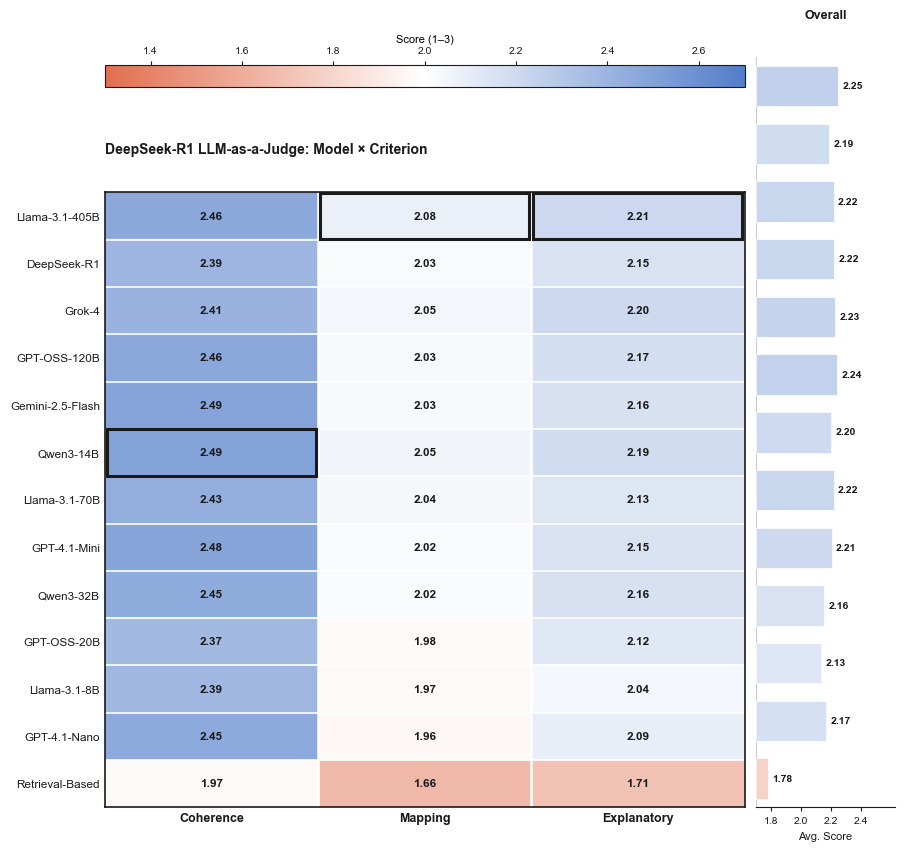

Saved → judge_heatmap_deepseek-r1.png


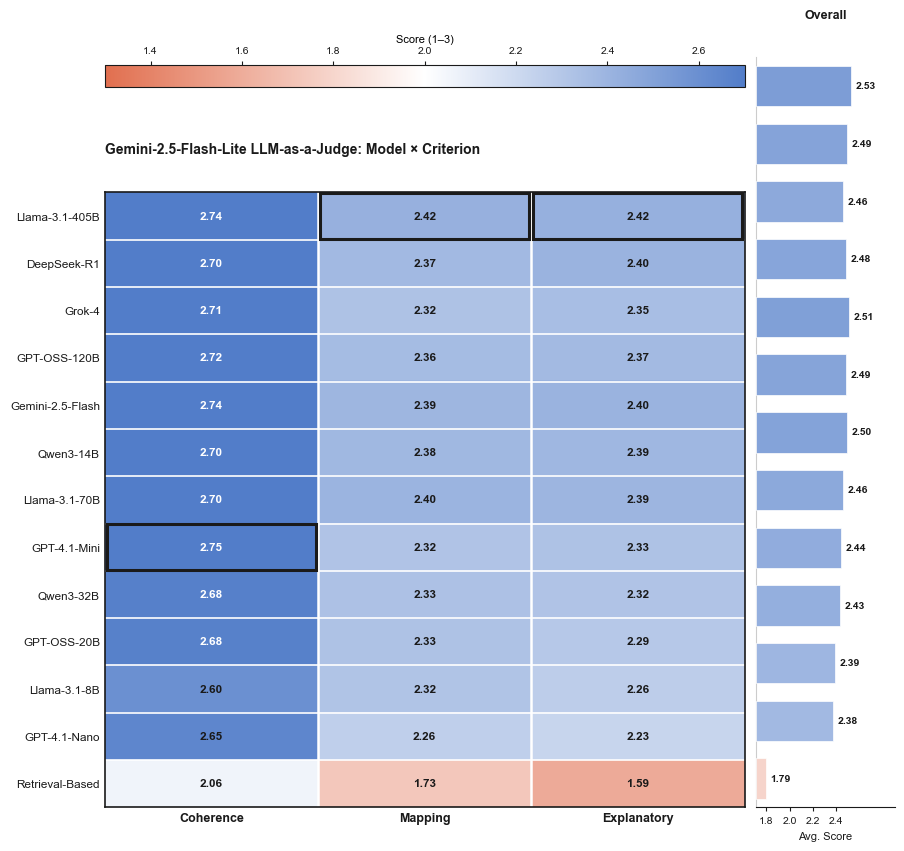

Saved → judge_heatmap_gemini-2-5-flash-lite.png


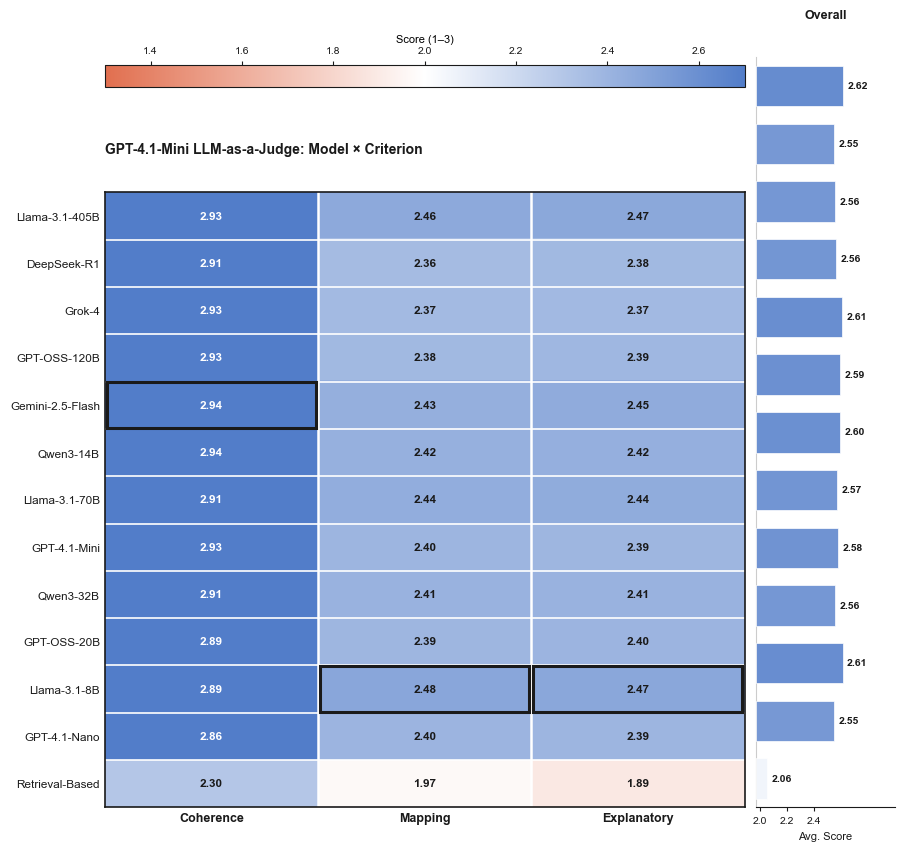

Saved → judge_heatmap_gpt-4-1-mini.png


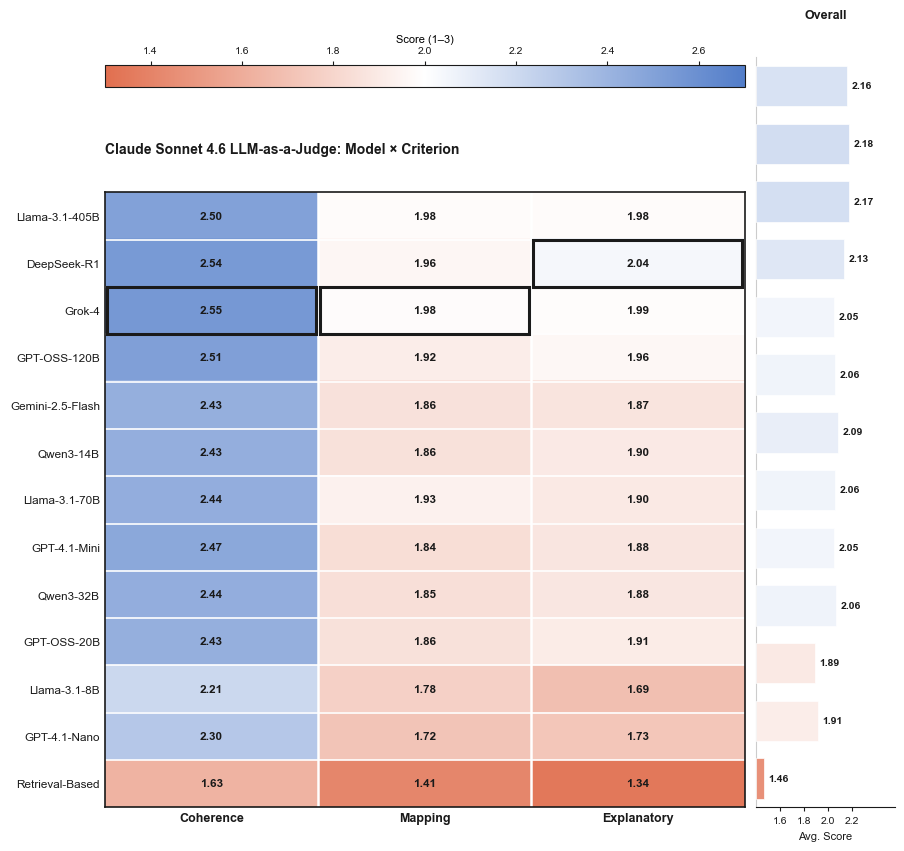

Saved → judge_heatmap_claude-sonnet-4-6.png


In [93]:
# ── Figure 1: one figure per judge ────────────────────────────────────────
n_models = len(shared_raw_order)

for j in JUDGES:
    fig, outer_gs = plt.subplots(
        1, 1,
        figsize=(10, max(7, n_models * 0.52 + 2.5)),
        facecolor='white',
    )
    # draw_panel expects a SubplotSpec; convert the axes to one via GridSpec
    outer_gs.remove()
    gs = gridspec.GridSpec(
        1, 1, figure=fig,
        left=0.18, right=0.97, top=0.87, bottom=0.06,
    )
    draw_panel(fig, gs[0, 0], judge_means[j['key']], j)

    fname = f'judge_heatmap_{j["key"].replace(".", "-")}.png'
    fig.savefig(OUTPUT_DIR / fname, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {fname}')

In [94]:
# ── Figure 2: Strategy comparison (Baseline | Embedding | Rerank) ──────────

def load_judge_all_strategies(judge_key: str) -> pd.DataFrame:
    """
    Load one judge CSV and return per-model per-strategy mean average_score.
    Includes stage-2 models with analogy_type in {baseline, embedding, rerank}
    and stage-1 retrieval-based (pipeline_results).
    """
    fpath = JUDGE_DIR / f'upgraded_judge_3scale_fewshot_{judge_key}.csv'
    df = pd.read_csv(fpath)
    df = df[df['status'] == 'success'].copy()

    stage2 = df[
        df['source_dataset'].str.startswith('stage2') &
        df['analogy_type'].isin(['baseline', 'embedding', 'rerank'])
    ]
    stage1 = df[
        df['source_dataset'].str.startswith('stage1') &
        (df['analogy_type'] == 'pipeline_results')
    ]
    # Map stage1 analogy_type to 'baseline' column for display
    stage1 = stage1.copy()
    stage1['analogy_type'] = 'pipeline_results'

    combined = pd.concat([stage2, stage1], ignore_index=True)
    means = combined.groupby(['model', 'analogy_type'])[AVG_COL].mean().unstack('analogy_type')
    return means


print('Loading all-strategy data...')
strategy_frames = [load_judge_all_strategies(j['key']) for j in JUDGES]

# Average across all 4 judges
strat_avg = pd.concat(strategy_frames).groupby(level=0).mean()

# Sort rows: LLM models by rerank score descending, Retrieval-Based last
llm_models  = [m for m in strat_avg.index if m != 'retrieval-based']
rerank_col  = strat_avg['rerank'] if 'rerank' in strat_avg.columns else strat_avg.iloc[:, -1]
llm_sorted  = strat_avg.loc[llm_models].sort_values('rerank', ascending=False)

retrieval_row = strat_avg.loc[['retrieval-based']] if 'retrieval-based' in strat_avg.index else pd.DataFrame()
strat_ordered = pd.concat([llm_sorted, retrieval_row])

# Build display matrix: columns = Baseline | Embedding | Rerank
# Retrieval-Based maps pipeline_results → 'baseline' display column
STRATEGY_MAP = {
    'baseline':         'Baseline',
    'embedding':        'Embedding',
    'rerank':           'Rerank',
    'pipeline_results': 'Baseline',   # retrieval-based appears in Baseline column
}

# Merge pipeline_results into baseline for retrieval-based row
if 'pipeline_results' in strat_ordered.columns and 'baseline' in strat_ordered.columns:
    strat_ordered['baseline'] = strat_ordered['baseline'].combine_first(
        strat_ordered['pipeline_results'])
elif 'pipeline_results' in strat_ordered.columns:
    strat_ordered['baseline'] = strat_ordered['pipeline_results']

display_cols   = ['baseline', 'embedding', 'rerank']
display_labels = ['Baseline', 'Embedding', 'Rerank']
hm_strat = strat_ordered.reindex(columns=display_cols).values  # (n_models, 3)

row_labels_strat = [MODEL_DISPLAY.get(m, m) for m in strat_ordered.index]
n_strat = len(row_labels_strat)
retrieval_idx = next(
    (i for i, m in enumerate(strat_ordered.index) if m == 'retrieval-based'), None)

print(f'Strategy matrix shape: {hm_strat.shape}')
print('Rows:', row_labels_strat)

Loading all-strategy data...
Strategy matrix shape: (13, 3)
Rows: ['Llama-3.1-405B', 'DeepSeek-R1', 'Grok-4', 'GPT-OSS-120B', 'Gemini-2.5-Flash', 'Qwen3-14B', 'Llama-3.1-70B', 'GPT-4.1-Mini', 'Qwen3-32B', 'GPT-OSS-20B', 'Llama-3.1-8B', 'GPT-4.1-Nano', 'Retrieval-Based']


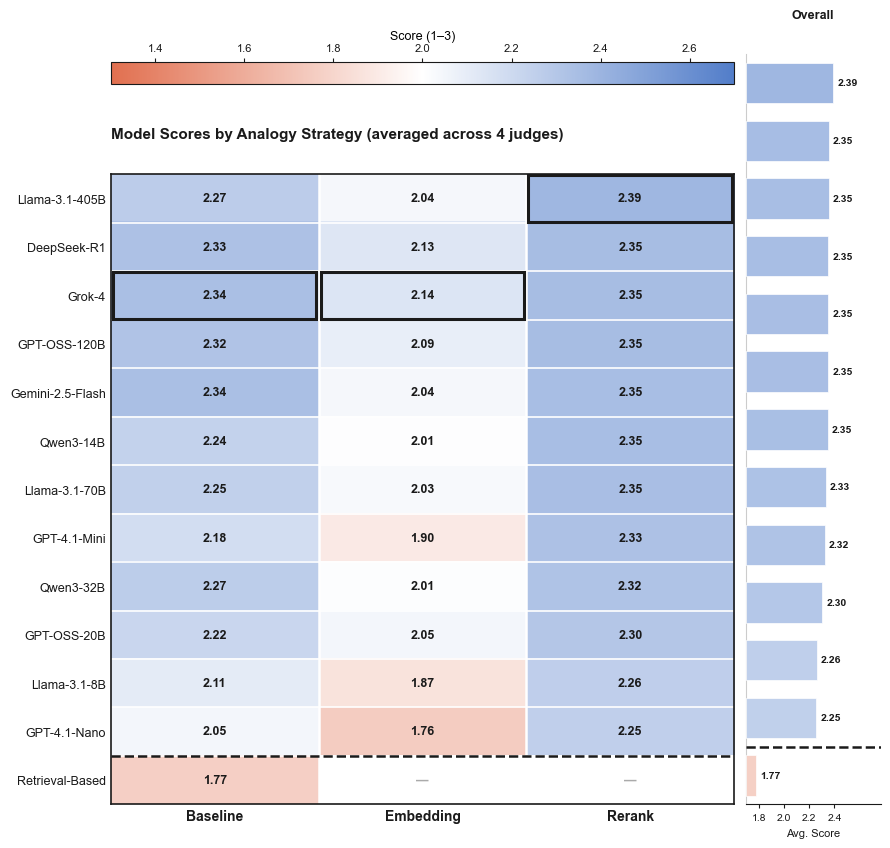

Saved → ..\results\judge_analysis\strategy_comparison_heatmap.png


In [95]:
# ── Draw Figure 2 — Strategy comparison ───────────────────────────────────
fig2_h = max(8, n_strat * 0.52 + 2.5)
fig2, outer2 = plt.subplots(1, 1, figsize=(10, fig2_h), facecolor='white')

gs2 = gridspec.GridSpec(
    1, 2, figure=fig2,
    width_ratios=[3, 0.65], wspace=0.03,
    left=0.20, right=0.97, top=0.87, bottom=0.06,
)
outer2.remove()

ax_h2 = fig2.add_subplot(gs2[0, 0])
ax_s2 = fig2.add_subplot(gs2[0, 1])

# Per-column max rows for bold border
strat_col_max = [int(np.nanargmax(hm_strat[:, ci])) for ci in range(3)]

# ── Heatmap ────────────────────────────────────────────────────────────────
im2 = ax_h2.imshow(hm_strat, cmap=THESIS_CMAP, norm=NORM, aspect='auto')

for ri in range(n_strat):
    for ci in range(3):
        val = hm_strat[ri, ci]
        if np.isnan(val):
            txt, tc = '—', '#aaaaaa'
        else:
            txt = f'{val:.2f}'
            rgba      = THESIS_CMAP(NORM(val))
            luminance = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
            tc = 'white' if luminance < 0.50 else '#1a1a1a'
        ax_h2.text(ci, ri, txt, ha='center', va='center',
                   fontsize=9, color=tc, fontweight='bold')

ax_h2.set_xticks([0, 1, 2])
ax_h2.set_xticklabels(display_labels, fontsize=10, fontweight='bold',
                      ha='center', va='top', color='#1a1a1a')
ax_h2.xaxis.set_ticks_position('bottom')
ax_h2.xaxis.set_label_position('bottom')

ax_h2.set_yticks(range(n_strat))
ax_h2.set_yticklabels(row_labels_strat, fontsize=9, color='#1a1a1a')
ax_h2.tick_params(axis='both', which='both', length=0)

ax_h2.set_xlim(-0.5, 2.5)
ax_h2.set_ylim(n_strat - 0.5, -0.5)

# White inner borders
for y in np.arange(0.5, n_strat - 0.5, 1):
    ax_h2.axhline(y, color='white', linewidth=1.2, zorder=2)
for x in [0.5, 1.5]:
    ax_h2.axvline(x, color='white', linewidth=1.8, zorder=2)

# Dashed separator above Retrieval-Based row
if retrieval_idx is not None:
    ax_h2.axhline(retrieval_idx - 0.5, color='#1a1a1a', linewidth=1.8,
                  linestyle='--', zorder=4)
    ax_s2.axhline(retrieval_idx - 0.5, color='#1a1a1a', linewidth=1.8,
                  linestyle='--', zorder=4)

# Black outer border
for sp in ax_h2.spines.values():
    sp.set_visible(True)
    sp.set_color('#1a1a1a')
    sp.set_linewidth(1.2)
ax_h2.set_facecolor('white')

# Bold black border on per-column maximum
for ci, ri in enumerate(strat_col_max):
    rect = mpatches.FancyBboxPatch(
        (ci - 0.49, ri - 0.49), 0.98, 0.98,
        boxstyle='square,pad=0',
        linewidth=2.2, edgecolor='#1a1a1a', facecolor='none', zorder=5,
    )
    ax_h2.add_patch(rect)

# Colorbar
cbar2 = fig2.colorbar(im2, ax=ax_h2, location='top',
                      pad=0.12, fraction=0.04, aspect=28,
                      ticks=CBAR_TICKS)
cbar2.set_label('Score (1–3)', fontsize=9, labelpad=3)
cbar2.ax.tick_params(labelsize=8, length=3, colors='#1a1a1a')
cbar2.ax.set_xticklabels([str(t) for t in CBAR_TICKS], fontsize=8)
cbar2.outline.set_edgecolor('#1a1a1a')

ax_h2.set_title(
    'Model Scores by Analogy Strategy (averaged across 4 judges)',
    fontsize=11, fontweight='bold', color='#1a1a1a', pad=26, loc='left',
)

# ── Side panel — horizontal bars ──────────────────────────────────────────
ov2 = hm_strat[:, 2].copy()
if retrieval_idx is not None and np.isnan(ov2[retrieval_idx]):
    ov2[retrieval_idx] = hm_strat[retrieval_idx, 0]

side_xmin2 = max(1.4, np.nanmin(ov2) - 0.08)
side_xmax2 = np.nanmax(ov2) + 0.20

bar_colors2 = [
    THESIS_CMAP(NORM(v)) if not np.isnan(v) else '#dddddd'
    for v in ov2
]

ax_s2.barh(
    np.arange(n_strat), ov2 - side_xmin2,
    left=side_xmin2, height=0.70,
    color=bar_colors2, edgecolor='white', linewidth=0.5, zorder=3,
)

for i, val in enumerate(ov2):
    if not np.isnan(val):
        ax_s2.text(val + (side_xmax2 - side_xmin2) * 0.04, i,
                   f'{val:.2f}',
                   va='center', ha='left',
                   fontsize=7.5, color='#1a1a1a', fontweight='bold')

ax_s2.set_ylim(n_strat - 0.5, -0.5)
ax_s2.set_xlim(side_xmin2, side_xmax2 + 0.18)
ax_s2.set_title('Overall', fontsize=9, fontweight='bold', color='#1a1a1a', pad=26)
ax_s2.set_xlabel('Avg. Score', fontsize=8, labelpad=4, color='#1a1a1a')
ax_s2.xaxis.set_ticks_position('bottom')
ax_s2.xaxis.set_label_position('bottom')

tick_vals2 = [v for v in [1.6, 1.8, 2.0, 2.2, 2.4]
              if side_xmin2 <= v <= side_xmax2]
ax_s2.set_xticks(tick_vals2)
ax_s2.set_xticklabels([f'{v:.1f}' for v in tick_vals2],
                      fontsize=7.5, color='#1a1a1a')
ax_s2.tick_params(axis='x', length=3, colors='#1a1a1a')
ax_s2.set_yticks(range(n_strat))
ax_s2.set_yticklabels([])
ax_s2.tick_params(axis='y', length=0)

for y in np.arange(0.5, n_strat - 0.5, 1):
    ax_s2.axhline(y, color='white', linewidth=1.2, zorder=2)

ax_s2.spines['top'].set_visible(False)
ax_s2.spines['right'].set_visible(False)
ax_s2.spines['left'].set_color('#cccccc')
ax_s2.spines['bottom'].set_color('#1a1a1a')
ax_s2.set_facecolor('white')

out2 = OUTPUT_DIR / 'strategy_comparison_heatmap.png'
fig2.savefig(out2, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out2}')

In [96]:
# ── Figure 3: Inter-judge agreement ───────────────────────────────────────
# Step 1: Load raw record-level scores and merge all 4 judges on record_id
# Only keep records evaluated by ALL 4 judges (inner join)

from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

JUDGE_SHORTS = ['deepseek', 'gemini', 'gpt', 'claude']
JUDGE_FULL   = {
    'deepseek': 'DeepSeek-R1',
    'gemini':   'Gemini-2.5-Flash-Lite',
    'gpt':      'GPT-4.1-Mini',
    'claude':   'Claude Sonnet 4.6',
}
JUDGE_KEY_MAP = {
    'deepseek': 'deepseek-r1',
    'gemini':   'gemini-2.5-flash-lite',
    'gpt':      'gpt-4.1-mini',
    'claude':   'claude-sonnet-4.6',
}
JUDGE_COLORS = {
    'deepseek': '#d7191c',
    'gemini':   '#fdae61',
    'gpt':      '#2c7bb6',
    'claude':   '#7b3294',
}

DIM_SHORT  = ['coh', 'map', 'exp']
DIM_FULL_N = {'coh': 'Coherence', 'map': 'Mapping Criterion', 'exp': 'Explanatory'}
DIM_RAW    = {'coh': 'analogy_coherence', 'map': 'mapping_soundness', 'exp': 'explanatory_power'}

META_COLS = ['record_id', 'source_dataset', 'model', 'analogy_type', 'original_mode']


def load_raw(judge_short: str) -> pd.DataFrame:
    """Load judge CSV, filter stage2-rerank + stage1-pipeline, return record-level scores."""
    key = JUDGE_KEY_MAP[judge_short]
    df  = pd.read_csv(JUDGE_DIR / f'upgraded_judge_3scale_fewshot_{key}.csv')
    df  = df[df['status'] == 'success'].copy()

    stage2 = df[df['source_dataset'].str.startswith('stage2') & (df['analogy_type'] == 'rerank')]
    stage1 = df[df['source_dataset'].str.startswith('stage1') & (df['analogy_type'] == 'pipeline_results')]
    combined = pd.concat([stage2, stage1], ignore_index=True)

    keep = META_COLS + [DIM_RAW['coh'], DIM_RAW['map'], DIM_RAW['exp'], AVG_COL]
    combined = combined[[c for c in keep if c in combined.columns]].copy()
    combined = combined.rename(columns={
        DIM_RAW['coh']: f'{judge_short}_coh',
        DIM_RAW['map']: f'{judge_short}_map',
        DIM_RAW['exp']: f'{judge_short}_exp',
        AVG_COL:        f'{judge_short}_avg',
    })
    print(f'  {judge_short:8s}: {len(combined):,} records')
    return combined


print('Loading raw record-level data for agreement analysis...')
raw = {}
for s in JUDGE_SHORTS:
    raw[s] = load_raw(s)

# Merge all 4 on record_id (inner join → only records scored by all 4)
merged = raw[JUDGE_SHORTS[0]][META_COLS].copy()
for s in JUDGE_SHORTS:
    score_cols = [f'{s}_coh', f'{s}_map', f'{s}_exp', f'{s}_avg']
    merged = merged.merge(
        raw[s][['record_id'] + score_cols],
        on='record_id', how='inner'
    )

print(f'\nRecords scored by all 4 judges: {len(merged):,}')
merged.head(3)

Loading raw record-level data for agreement analysis...
  deepseek: 7,985 records
  gemini  : 7,985 records
  gpt     : 7,985 records
  claude  : 7,984 records

Records scored by all 4 judges: 7,984


,record_id,source_dataset,model,analogy_type,original_mode,deepseek_coh,deepseek_map,deepseek_exp,deepseek_avg,gemini_coh,...,gemini_exp,gemini_avg,gpt_coh,gpt_map,gpt_exp,gpt_avg,claude_coh,claude_map,claude_exp,claude_avg
0,stage2_targetonly__deepseek-r1__1__rerank,stage2_targetonly,deepseek-r1,rerank,targetonly,1,1,1,1.0000,3,...,2,2.6667,3.0,3.0,3.0,3.0000,1.0,1.0,1.0,1.0000
1,stage2_targetonly__deepseek-r1__2__rerank,stage2_targetonly,deepseek-r1,rerank,targetonly,2,2,2,2.0000,3,...,2,2.3333,2.0,2.0,2.0,2.0000,2.0,2.0,2.0,2.0000
2,stage2_targetonly__deepseek-r1__3__rerank,stage2_targetonly,deepseek-r1,rerank,targetonly,3,2,2,2.3333,3,...,2,2.3333,3.0,2.0,2.0,2.3333,3.0,2.0,2.0,2.3333


In [97]:
# ── Step 2: Compute pairwise Spearman correlations per dimension ───────────

n_judges = len(JUDGE_SHORTS)
pairs    = [(JUDGE_SHORTS[i], JUDGE_SHORTS[j])
            for i in range(n_judges) for j in range(i+1, n_judges)]


def spearman_matrix(df, dim_suffix):
    """Return (n_judges × n_judges) Spearman rho matrix for a given dimension."""
    mat = np.ones((n_judges, n_judges))
    for i, ji in enumerate(JUDGE_SHORTS):
        for j, jj in enumerate(JUDGE_SHORTS):
            if i == j:
                continue
            col_i = f'{ji}_{dim_suffix}'
            col_j = f'{jj}_{dim_suffix}'
            mask  = df[col_i].notna() & df[col_j].notna()
            rho, _ = stats.spearmanr(df.loc[mask, col_i], df.loc[mask, col_j])
            mat[i, j] = rho
    return mat


# Per-dimension + overall (avg)
dims_to_analyse = DIM_SHORT + ['avg']
rho_matrices = {d: spearman_matrix(merged, d) for d in dims_to_analyse}

# ── Krippendorff's alpha (ordinal, 4 raters) ───────────────────────────────
def krippendorff_alpha_ordinal(ratings: np.ndarray) -> float:
    """
    Krippendorff's alpha for N raters, ordinal metric.
    ratings: (n_items, n_raters), integer values in {1,2,3}.
    """
    data  = ratings.astype(float)
    mask  = ~np.any(np.isnan(data), axis=1)
    data  = data[mask]
    n, m  = data.shape
    if n < 2:
        return np.nan

    unique_vals = np.array([1.0, 2.0, 3.0])
    n_cats      = len(unique_vals)
    all_flat    = data.flatten()
    data_idx    = (data - 1).astype(int)

    # Ordinal distance: squared rank difference using cumulative frequencies
    val_freq = np.array([(all_flat == v).sum() for v in unique_vals], dtype=float)
    dist = np.zeros((n_cats, n_cats))
    for ii in range(n_cats):
        for jj in range(n_cats):
            if ii == jj:
                continue
            lo, hi = min(ii, jj), max(ii, jj)
            n_g = val_freq[lo: hi + 1].sum()
            dist[ii, jj] = (n_g - (val_freq[lo] + val_freq[hi]) / 2) ** 2

    # Coincidences matrix
    C      = np.zeros((n_cats, n_cats), dtype=float)
    weight = 1.0 / (m - 1)
    for u in range(m):
        for v in range(m):
            if u == v:
                continue
            hist, _, _ = np.histogram2d(
                data_idx[:, u], data_idx[:, v],
                bins=n_cats, range=[[-0.5, n_cats-0.5]] * 2
            )
            C += weight * hist

    n_c     = C.sum(axis=1)
    n_total = n_c.sum()
    D_o     = np.sum(C * dist) / n_total
    D_e     = np.sum(np.outer(n_c, n_c) * dist) / (n_total * (n_total - 1))
    return float(1 - D_o / D_e) if D_e != 0 else 1.0


# Exact agreement %
def pct_exact_4(df, dim):
    cols  = [f'{s}_{dim}' for s in JUDGE_SHORTS]
    valid = df[cols].dropna()
    arr   = valid.values.astype(int)
    return float((arr.min(axis=1) == arr.max(axis=1)).mean() * 100)


# Summary table
rows = []
for d in dims_to_analyse:
    cols   = [f'{s}_{d}' for s in JUDGE_SHORTS]
    valid  = merged[cols].dropna().values.astype(float)
    alpha  = krippendorff_alpha_ordinal(valid) if d != 'avg' else np.nan
    exact  = pct_exact_4(merged, d) if d != 'avg' else np.nan
    # mean pairwise rho (off-diagonal)
    rho_m  = rho_matrices[d]
    mean_rho = rho_m[np.triu_indices(n_judges, k=1)].mean()
    rows.append({
        'Dimension':       DIM_FULL_N.get(d, 'Average'),
        'Krippendorff α':  round(alpha, 3) if not np.isnan(alpha) else '—',
        'Mean pairwise ρ': round(mean_rho, 3),
        '% Exact agree':   round(exact, 1) if not np.isnan(exact) else '—',
    })

summary_df = pd.DataFrame(rows).set_index('Dimension')
print('=== Inter-Judge Agreement Summary ===')
print(summary_df.to_string())

# Print all pairwise rho for overall avg
print('\nPairwise Spearman ρ on average_score:')
for ji, jj in pairs:
    i, j = JUDGE_SHORTS.index(ji), JUDGE_SHORTS.index(jj)
    print(f'  {JUDGE_FULL[ji]:25s} vs {JUDGE_FULL[jj]:25s}: ρ = {rho_matrices["avg"][i,j]:.3f}')

=== Inter-Judge Agreement Summary ===
                  Krippendorff α  Mean pairwise ρ % Exact agree
Dimension                                                      
Coherence                  0.297            0.396          37.7
Mapping Criterion           0.25            0.340          30.1
Explanatory                 0.31            0.371          27.3
Average                        —            0.443             —

Pairwise Spearman ρ on average_score:
  DeepSeek-R1               vs Gemini-2.5-Flash-Lite    : ρ = 0.482
  DeepSeek-R1               vs GPT-4.1-Mini             : ρ = 0.411
  DeepSeek-R1               vs Claude Sonnet 4.6        : ρ = 0.469
  Gemini-2.5-Flash-Lite     vs GPT-4.1-Mini             : ρ = 0.476
  Gemini-2.5-Flash-Lite     vs Claude Sonnet 4.6        : ρ = 0.464
  GPT-4.1-Mini              vs Claude Sonnet 4.6        : ρ = 0.357


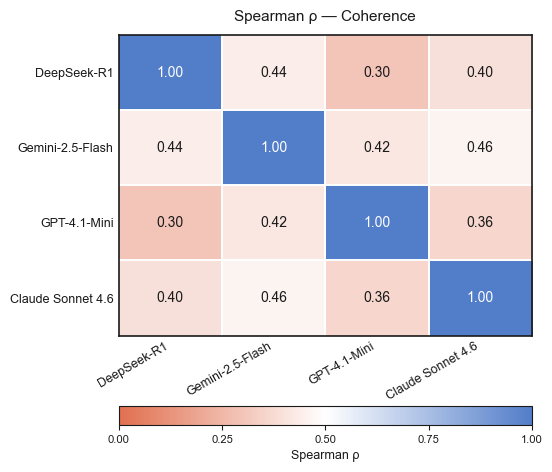

Saved → judge_agreement_corr_coh.png


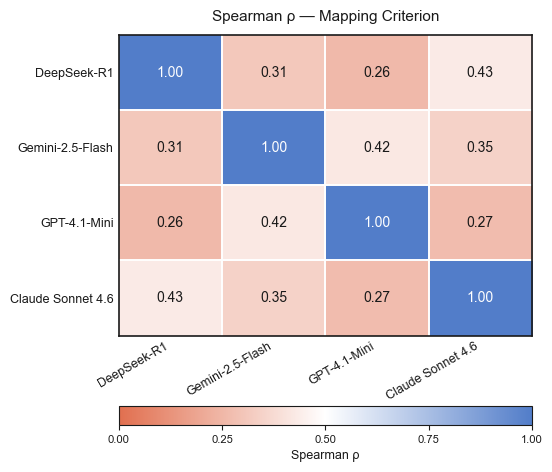

Saved → judge_agreement_corr_map.png


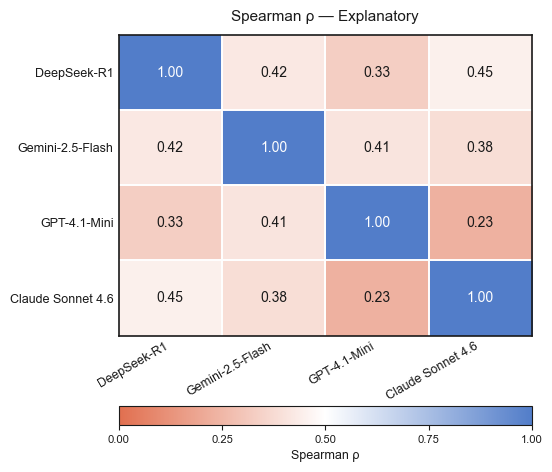

Saved → judge_agreement_corr_exp.png


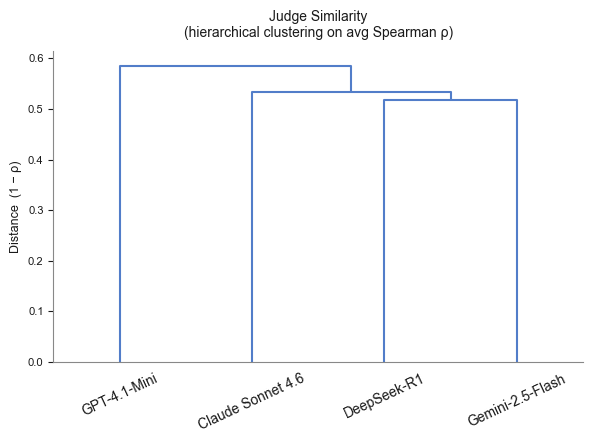

Saved → ..\results\judge_analysis\judge_agreement_dendrogram.png

                  Krippendorff α  Mean pairwise ρ % Exact agree
Dimension                                                      
Coherence                  0.297            0.396          37.7
Mapping Criterion           0.25            0.340          30.1
Explanatory                 0.31            0.371          27.3
Average                        —            0.443             —


In [99]:
# ── Figure 3a: Spearman ρ heatmaps — one per dimension ────────────────────
JUDGE_SHORT_LABELS = {
    'deepseek': 'DeepSeek-R1',
    'gemini':   'Gemini-2.5-Flash',
    'gpt':      'GPT-4.1-Mini',
    'claude':   'Claude Sonnet 4.6',
}
judge_labels_short = [JUDGE_SHORT_LABELS[s] for s in JUDGE_SHORTS]

CORR_NORM  = mcolors.TwoSlopeNorm(vmin=0.0, vcenter=0.5, vmax=1.0)
CORR_TICKS = [0.0, 0.25, 0.5, 0.75, 1.0]

for dim in DIM_SHORT:
    mat = rho_matrices[dim]

    fig, ax = plt.subplots(figsize=(5.5, 4.8), facecolor='white')

    im = ax.imshow(mat, cmap=THESIS_CMAP, norm=CORR_NORM, aspect='auto')

    for ri in range(n_judges):
        for ci in range(n_judges):
            val  = mat[ri, ci]
            txt  = '1.00' if ri == ci else f'{val:.2f}'
            rgba = THESIS_CMAP(CORR_NORM(val))
            lum  = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
            tc   = 'white' if lum < 0.50 else '#1a1a1a'
            ax.text(ci, ri, txt, ha='center', va='center',
                    fontsize=10, color=tc)

    ax.set_xticks(range(n_judges))
    ax.set_xticklabels(judge_labels_short, fontsize=9, rotation=30,
                       ha='right', color='#1a1a1a')
    ax.set_yticks(range(n_judges))
    ax.set_yticklabels(judge_labels_short, fontsize=9, color='#1a1a1a')
    ax.tick_params(length=0)

    for x in np.arange(0.5, n_judges - 0.5, 1):
        ax.axvline(x, color='white', linewidth=1.4, zorder=2)
    for y in np.arange(0.5, n_judges - 0.5, 1):
        ax.axhline(y, color='white', linewidth=1.4, zorder=2)
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_color('#1a1a1a')
        sp.set_linewidth(1.2)

    ax.set_title(f'Spearman ρ — {DIM_FULL_N[dim]}',
                 fontsize=11, color='#1a1a1a', pad=10)

    cbar = fig.colorbar(im, ax=ax, orientation='horizontal',
                        pad=0.18, fraction=0.05, aspect=22,
                        ticks=CORR_TICKS)
    cbar.set_label('Spearman ρ', fontsize=9, color='#1a1a1a')
    cbar.ax.tick_params(labelsize=8, colors='#1a1a1a')
    cbar.outline.set_edgecolor('#1a1a1a')

    fig.tight_layout()
    fname = f'judge_agreement_corr_{dim}.png'
    fig.savefig(OUTPUT_DIR / fname, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {fname}')


# ── Figure 3b: Dendrogram ─────────────────────────────────────────────────
rho_avg  = rho_matrices['avg']
dist_mat = 1.0 - rho_avg
np.fill_diagonal(dist_mat, 0.0)
dist_vec = squareform(dist_mat, checks=False)
Z        = linkage(dist_vec, method='average')

fig3b, ax_dend = plt.subplots(figsize=(6, 4.5), facecolor='white')

dend = dendrogram(
    Z,
    labels=judge_labels_short,
    orientation='top',
    ax=ax_dend,
    color_threshold=0,
    above_threshold_color='#527dc9',
    leaf_rotation=25,
    leaf_font_size=10,
)

for tick in ax_dend.get_xticklabels():
    tick.set_color('#1a1a1a')
    tick.set_fontweight('normal')

ax_dend.set_ylabel('Distance  (1 − ρ)', fontsize=9, color='#1a1a1a')
ax_dend.set_title(
    'Judge Similarity\n(hierarchical clustering on avg Spearman ρ)',
    fontsize=10, color='#1a1a1a', pad=10,
)
ax_dend.spines['top'].set_visible(False)
ax_dend.spines['right'].set_visible(False)
ax_dend.spines['left'].set_color('#888888')
ax_dend.spines['bottom'].set_color('#888888')
ax_dend.tick_params(axis='y', labelsize=8, colors='#1a1a1a')
ax_dend.tick_params(axis='x', colors='#1a1a1a')
ax_dend.set_facecolor('white')

fig3b.tight_layout()
out3b = OUTPUT_DIR / 'judge_agreement_dendrogram.png'
fig3b.savefig(out3b, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out3b}')

print()
print(summary_df.to_string())
